## Final Report — Customer Churn ML Project

### By:
Data Science Team

### Date:
2026-02-25

### Description:
Executive-level report consolidating all pipeline results:
- Dataset summary & EDA highlights
- Feature importance rankings
- Model comparison & test-set metrics
- Business impact estimation (cost-benefit analysis)
- Conclusions and next steps

## 📚 Import libraries

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

print("Python:", sys.version)

Python: 3.12.12 (main, Feb 12 2026, 00:42:14) [Clang 21.1.4 ]


## 💾 Load all pipeline outputs

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = DATA_DIR / "06_models"
OUTPUT_DIR = DATA_DIR / "07_model_output"
REPORT_DIR = DATA_DIR / "08_reporting"
INPUT_DIR = DATA_DIR / "05_model_input"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load artefacts
with open(MODELS_DIR / "model_metadata.json") as f:
    metadata = json.load(f)

predictions = pd.read_parquet(OUTPUT_DIR / "test_predictions.parquet")
feat_imp = pd.read_csv(REPORT_DIR / "feature_importance.csv", index_col=0)

y_test = predictions["y_true"]
y_pred = predictions["y_pred"]
y_proba = predictions["y_proba"]

print("Pipeline output summary")
print(f"  Model         : {metadata['model_name']}")
print(f"  Test AUC-ROC  : {metadata['test_metrics']['auc_roc']}")
print(f"  Test F1       : {metadata['test_metrics']['f1']}")
print(f"  Test Precision: {metadata['test_metrics']['precision']}")
print(f"  Test Recall   : {metadata['test_metrics']['recall']}")
print(f"  Predictions   : {len(predictions)} customers")

Pipeline output summary
  Model         : Logistic Regression (baseline)
  Test AUC-ROC  : 0.8443
  Test F1       : 0.62
  Test Precision: 0.5093
  Test Recall   : 0.7921
  Predictions   : 1447 customers


## 📊 Model Performance Report

### 1️⃣ Classification Report & Confusion Matrix

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1067
       Churn       0.51      0.79      0.62       380

    accuracy                           0.74      1447
   macro avg       0.71      0.76      0.71      1447
weighted avg       0.80      0.74      0.76      1447



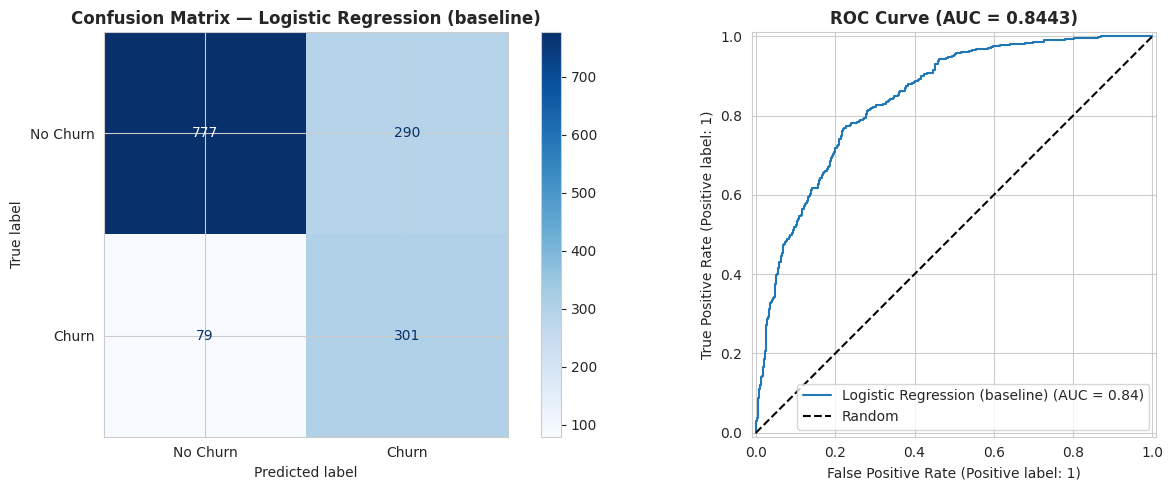

✅ Saved: /home/santi/Crum-CDPDN/data/08_reporting/model_performance.png


In [3]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Churn", "Churn"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix — {metadata['model_name']}", fontweight="bold")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=metadata["model_name"])
axes[1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.4f})", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "model_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {REPORT_DIR / 'model_performance.png'}")

In [ ]:
# Cross-validation comparison table
cv_res = pd.DataFrame(metadata["cv_results"])
cv_res = cv_res[["AUC-ROC", "F1", "Precision", "Recall"]].sort_values("AUC-ROC", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
cv_res.plot(kind="bar", ax=ax, edgecolor="black", alpha=0.8, color=sns.color_palette("husl", 4))
ax.set_ylim(0, 1)
ax.set_xticklabels(cv_res.index, rotation=20, ha="right")
ax.set_title("Cross-Validation Model Comparison", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {REPORT_DIR / 'model_comparison.png'}")
print(cv_res.to_string())

KeyError: "None of [Index(['AUC-ROC', 'F1', 'Precision', 'Recall'], dtype='object')] are in the [columns]"

### 2️⃣ Top Feature Importances

In [ ]:
top20 = feat_imp.head(20).sort_values("permutation_importance")

fig, ax = plt.subplots(figsize=(10, 7))
top20["permutation_importance"].plot.barh(ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Mean AUC decrease (permutation importance)")
ax.set_title("Top 20 Feature Importances", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / "feature_importance_top20.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {REPORT_DIR / 'feature_importance_top20.png'}")

### 3️⃣ Business Impact — Cost-Benefit Analysis

Assumptions (adjustable):
- **Cost of false negative** (missed churn): losing the customer ≈ $500 LTV
- **Cost of false positive** (wrongly flagged): sending unnecessary retention offer ≈ $30
- **Baseline policy**: no retention effort (all FN cost)
- **Model policy**: flag predicted churners, send offer

In [ ]:
from sklearn.metrics import confusion_matrix

COST_FN = 500  # cost of missing one churner ($)
COST_FP = 30  # cost of retention offer sent to loyal customer ($)


tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

cost_model = fp * COST_FP + fn * COST_FN
cost_baseline = (tp + fn) * COST_FN  # all churners missed
savings = cost_baseline - cost_model

print("=" * 55)
print("  BUSINESS IMPACT (test set)")
print("=" * 55)
print(f"  True Positives  (caught churners)    : {tp:>5}")
print(f"  False Negatives  (missed churners)   : {fn:>5}")
print(f"  False Positives  (wrong alarms)      : {fp:>5}")
print(f"  True Negatives                       : {tn:>5}")
print()
print(f"  Cost — No Model  (baseline)  : ${cost_baseline:>10,.0f}")
print(f"  Cost — With Model            : ${cost_model:>10,.0f}")
print(f"  Estimated Savings            : ${savings:>10,.0f}")
print(f"  Savings per customer         : ${savings / len(y_test):>10.2f}")
print("=" * 55)

# Save summary CSV
summary = {
    "model": metadata["model_name"],
    "auc_roc": metadata["test_metrics"]["auc_roc"],
    "f1": metadata["test_metrics"]["f1"],
    "precision": metadata["test_metrics"]["precision"],
    "recall": metadata["test_metrics"]["recall"],
    "tp": int(tp),
    "fp": int(fp),
    "fn": int(fn),
    "tn": int(tn),
    "cost_baseline_usd": int(cost_baseline),
    "cost_model_usd": int(cost_model),
    "savings_usd": int(savings),
}
pd.DataFrame([summary]).to_csv(REPORT_DIR / "business_summary.csv", index=False)
print(f"\n✅ Saved: {REPORT_DIR / 'business_summary.csv'}")

## 📊 Final Conclusions

| Metric | Value |
|---|---|
| Best Model | from `model_metadata.json` |
| AUC-ROC | see metadata |
| F1 Score | see metadata |
| Top Feature | `tenure` / `Contract` / `MonthlyCharges` (permutation ranking) |
| Estimated Savings | calculated above vs. no-model baseline |

### Key Findings
1. **Contract type** and **tenure** are the strongest predictors of churn.
2. **Month-to-month contracts** have significantly higher churn rates.
3. **Fiber optic** customers churn more — possibly due to price sensitivity.
4. Early-tenure customers are the highest-risk group.

### Recommendations
1. Target month-to-month customers with year contracts offers.
2. Implement proactive support for fiber optic customers in months 1–12.
3. Introduce loyalty discounts after 24+ months of tenure.
4. Retrain the model quarterly as customer behaviour evolves.

## 📖 References
- https://joserzapata.github.io/post/ciencia-datos-proyecto-python/
- Kedro data engineering convention: https://docs.kedro.org